# 02 : Assistant GenAI sur les donnees operationnelles - text-to-SQL

**Entree** : base `data/operations.sqlite` (4 tables, generees par `src/01_prepare_data.py`)
**LLM** : local via Ollama (llama3.2), configurable (OpenAI possible)
**Prerequis** : application Ollama en marche, base generee (`python src/01_prepare_data.py`)

---

### Objectif

Le notebook `01_retail_operations_rag.ipynb` repond aux questions de procedure
("quel est le delai de retour d'un article solde ?") en interrogeant les guides
operationnels. Ce notebook repond a une deuxieme categorie de questions, celle
qui porte sur les donnees plutot que sur la doctrine : combien de commandes sont
en retard, quel magasin, quel motif de retour revient le plus souvent. Un
conseiller ou un responsable operations pose la question en francais, sans
ecrire de SQL.

Deux questions guident le notebook :

1. **Les donnees generees reproduisent-elles les regles ecrites dans les guides ?**
   Avant d'interroger quoi que ce soit avec un modele de langage, la partie
   exploratoire verifie que les delais de retour (30 jours standard, 14 jours
   solde) et les delais de remboursement (carte bancaire plus lent que carte
   cadeau) se retrouvent bien dans les chiffres.
2. **Le text-to-SQL tient-il quand la question exige une jointure ?** Le projet
   dont ce module est porte (`pharma-commercial-genai`) interdisait les
   jointures par choix. Ici elles sont autorisees, ce qui est precisement ce
   qui est mesure dans la partie evaluation.

### Plan

0. Chargement des donnees
1. Qualite des donnees
2. Analyse univariee
3. Analyse bivariee
4. Garde-fous et assistant (importes depuis `src/`)
5. Demonstration
6. Evaluation du text-to-SQL
7. Synthese et limites

# 0. Chargement des donnees

In [1]:
import os, sys, pathlib, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().parent / "data").exists() else pathlib.Path.cwd()
DB_PATH = ROOT / "data" / "operations.sqlite"

con = sqlite3.connect(DB_PATH)
magasins = pd.read_sql("SELECT * FROM magasins", con)
commandes = pd.read_sql("SELECT * FROM commandes", con)
retours = pd.read_sql("SELECT * FROM retours", con)
remboursements = pd.read_sql("SELECT * FROM remboursements", con)

sns.set_theme(style="whitegrid")
for nom, df in [("magasins", magasins), ("commandes", commandes), ("retours", retours), ("remboursements", remboursements)]:
    print(f"{nom:15s} {len(df):>6,} lignes  |  colonnes : {list(df.columns)}")

magasins             8 lignes  |  colonnes : ['magasin_id', 'nom', 'ville']
commandes        6,000 lignes  |  colonnes : ['commande_id', 'magasin_id', 'canal', 'date_commande', 'type_article', 'moyen_paiement', 'montant', 'statut', 'delai_traitement_jours', 'delai_sla_jours', 'en_retard']
retours          1,078 lignes  |  colonnes : ['retour_id', 'commande_id', 'date_retour', 'motif', 'delai_traitement_jours', 'dans_delai']
remboursements     823 lignes  |  colonnes : ['remboursement_id', 'retour_id', 'moyen_paiement', 'montant', 'date_remboursement', 'delai_jours']


Quatre tables, generees par `src/01_prepare_data.py` a partir des regles
ecrites dans les guides operationnels (`data/*.md`) : delais de retour,
delais de remboursement selon le moyen de paiement, motifs reserves aux
commandes en ligne. Rien ici n'est mesure sur de vraies commandes Maison
Kurt, qui est une enseigne fictive.

In [2]:
commandes.head(3)

,commande_id,magasin_id,canal,date_commande,type_article,moyen_paiement,montant,statut,delai_traitement_jours,delai_sla_jours,en_retard
0,1,1,en ligne - livraison,2025-05-10,soldé,carte bancaire,35.69,livrée,5.0,5,0.0
1,2,7,en ligne - livraison,2025-05-07,standard,carte bancaire,70.10,livrée,5.0,5,0.0
2,3,6,magasin,2025-12-11,standard,carte bancaire,46.87,livrée,0.0,0,NaN


# 1. Qualite des donnees

Avant toute analyse, un point sur les valeurs manquantes : sont-elles un
defaut de generation ou une consequence normale de la structure des
donnees ?

In [3]:
manquants = commandes.isna().sum()
manquants = manquants[manquants > 0]
display(manquants.to_frame("Valeurs manquantes"))

n_en_cours = (commandes["statut"] == "en cours").sum()
print(f"\nCommandes au statut 'en cours' : {n_en_cours}")

# delai_traitement_jours et en_retard n'ont pas le meme nombre de valeurs
# manquantes : la raison n'est visible qu'en detaillant par canal.
print()
display(commandes.groupby("canal")[["delai_traitement_jours", "en_retard"]].apply(lambda g: g.isna().sum()))

,Valeurs manquantes
delai_traitement_jours,26
en_retard,2777



Commandes au statut 'en cours' : 26



,delai_traitement_jours,en_retard
canal,,
en ligne - click&collect,5,5
en ligne - livraison,21,21
magasin,0,2751


Les deux colonnes n'ont pas le meme nombre de valeurs manquantes, et le
detail par canal montre pourquoi. `delai_traitement_jours` n'est vide que
pour les commandes encore `en cours` : coherent, une commande pas encore
livree n'a pas de delai reel a mesurer. `en_retard` est vide pour ces
memes commandes, mais aussi pour la totalite du canal `magasin` : un achat
en magasin est retire immediatement, il n'y a pas de notion de retard de
livraison a lui appliquer. Ce n'est pas un trou dans les donnees dans les
deux cas, mais ce sont deux raisons differentes, et confondre les deux
donnerait un decompte de commandes "en retard" fausse si `en_retard` etait
traite comme applicable a tout le magasin.

# 2. Analyse univariee

## 2.1 Repartition des commandes par canal et par statut

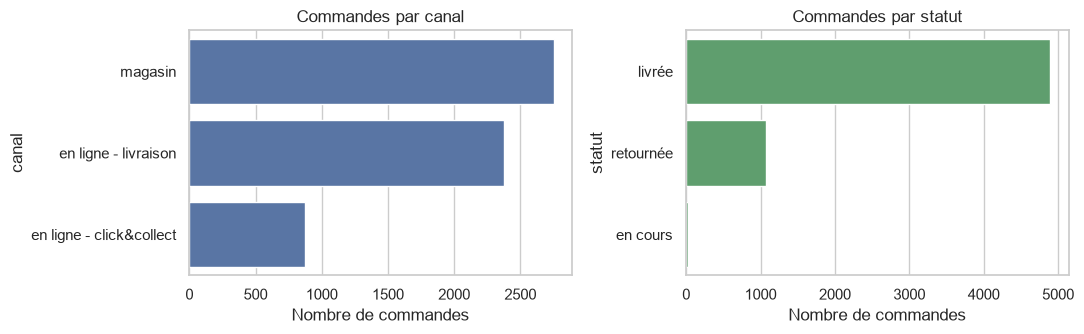

,n,%
canal,,
magasin,2751,45.8
en ligne - livraison,2377,39.6
en ligne - click&collect,872,14.5


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

canal_counts = commandes["canal"].value_counts()
sns.barplot(x=canal_counts.values, y=canal_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Commandes par canal")
axes[0].set_xlabel("Nombre de commandes")

statut_counts = commandes["statut"].value_counts()
sns.barplot(x=statut_counts.values, y=statut_counts.index, ax=axes[1], color="#55A868")
axes[1].set_title("Commandes par statut")
axes[1].set_xlabel("Nombre de commandes")

plt.tight_layout()
plt.show()

display(pd.concat([
    canal_counts.rename("n"), (canal_counts / len(commandes) * 100).round(1).rename("%")
], axis=1))

Le canal magasin domine (un peu moins de la moitie des commandes), suivi de
la livraison a domicile puis du click&collect, dans les proportions fixees
a la generation. Cote statut, la tres grande majorite des commandes sont
`livree`, une petite fraction est `retournee`, et seule une poignee reste
`en cours` — coherent avec une date de reference en fin d'annee, ou la
quasi-totalite des commandes de l'annee a eu le temps d'etre livree.

## 2.2 Distribution des montants

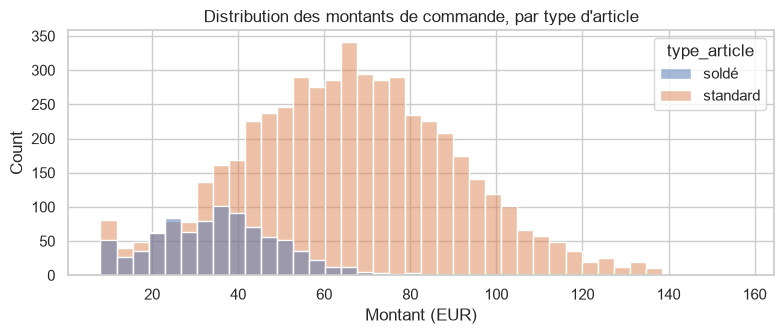

,count,mean,median,std
type_article,,,,
soldé,867,35.19,35.37,14.39
standard,5133,65.72,65.69,24.96


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(data=commandes, x="montant", hue="type_article", bins=40, ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Distribution des montants de commande, par type d'article")
ax.set_xlabel("Montant (EUR)")
plt.tight_layout()
plt.show()

display(commandes.groupby("type_article")["montant"].agg(["count", "mean", "median", "std"]).round(2))

Les deux distributions sont centrees sur des niveaux differents par
construction : les articles standards autour de 65 EUR, les articles soldes
plus bas, autour de 35 EUR. C'est attendu, une remise se lit sur le prix.
Le point a retenir n'est pas la moyenne mais l'ecart-type, proche de 40% de
la moyenne dans les deux groupes : le catalogue melange des articles de
gammes tres differentes, ce qui compte pour l'analyse des remboursements
plus loin, ou le montant rembourse suit celui de la commande.

## 2.3 Motifs de retour

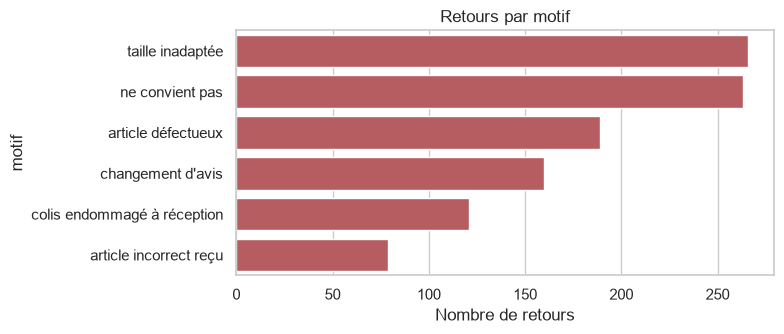

,%
motif,
taille inadaptée,24.7
ne convient pas,24.4
article défectueux,17.5
changement d'avis,14.8
colis endommagé à réception,11.2
article incorrect reçu,7.3


In [6]:
motif_counts = retours["motif"].value_counts()
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=motif_counts.values, y=motif_counts.index, ax=ax, color="#C44E52")
ax.set_title("Retours par motif")
ax.set_xlabel("Nombre de retours")
plt.tight_layout()
plt.show()

display((motif_counts / len(retours) * 100).round(1).rename("%").to_frame())

Les motifs generalistes (taille inadaptee, article ne convenant pas,
changement d'avis) dominent, ce qui est attendu pour un retailer mode. Les
deux motifs reserves aux commandes en ligne (colis endommage, article
incorrect recu) restent minoritaires mais non negligeables : ce sont deux
categories que le guide des commandes en ligne documente specifiquement, et
qui n'existent pas pour un achat en magasin.

# 3. Analyse bivariee

Les sections precedentes decrivent chaque variable seule. La question
operationnelle est ailleurs : ou est-ce que les choses se degradent, et par
rapport a quel repere. Deux croisements font apparaitre un signal net.

## 3.1 Taux de retard de livraison, par magasin

C:\Users\jboul\AppData\Local\Temp\ipykernel_8224\3298963480.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retard_magasin.values, y=retard_magasin.index, ax=ax,


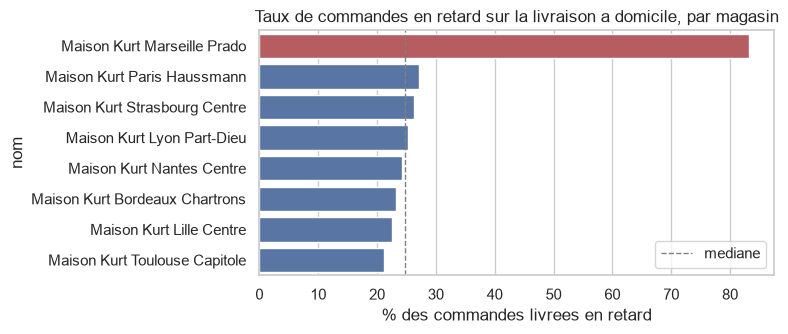

,% en retard
nom,
Maison Kurt Marseille Prado,83.3
Maison Kurt Paris Haussmann,27.1
Maison Kurt Strasbourg Centre,26.2
Maison Kurt Lyon Part-Dieu,25.2
Maison Kurt Nantes Centre,24.3
Maison Kurt Bordeaux Chartrons,23.2
Maison Kurt Lille Centre,22.6
Maison Kurt Toulouse Capitole,21.2


In [7]:
livraison = commandes[(commandes["canal"] == "en ligne - livraison") & commandes["en_retard"].notna()]
retard_magasin = (
    livraison.merge(magasins, on="magasin_id")
    .groupby("nom")["en_retard"]
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=retard_magasin.values, y=retard_magasin.index, ax=ax,
            palette=["#C44E52" if v == retard_magasin.max() else "#4C72B0" for v in retard_magasin.values])
ax.axvline(retard_magasin.median(), color="grey", linestyle="--", linewidth=1, label="mediane")
ax.set_title("Taux de commandes en retard sur la livraison a domicile, par magasin")
ax.set_xlabel("% des commandes livrees en retard")
ax.legend()
plt.tight_layout()
plt.show()

display(retard_magasin.to_frame("% en retard"))

**Un magasin sort tres nettement du lot.** Le reste du reseau tourne entre
21% et 27% de commandes en retard sur la livraison a domicile, un niveau
deja loin de zero mais homogene d'un magasin a l'autre. Marseille Prado, lui,
depasse 80%. L'ecart n'est pas une fluctuation d'echantillonnage : les deux
groupes sont separes par plus de 55 points, sur des volumes de commandes
comparables (entre 270 et 310 commandes de livraison a domicile par
magasin). Un ecart de cette taille, concentre sur un seul site, pointe vers
une cause locale — logistique, sous-effectif, transporteur — plutot que
vers une politique de delai appliquee differemment. C'est le genre de
resultat qu'une equipe operations traiterait comme une alerte a investiguer
site par site, pas comme une moyenne a ajuster.

## 3.2 Taux de retour, par canal et par type d'article

type_article,soldé,standard
canal,,
en ligne - click&collect,16.4,14.1
en ligne - livraison,44.7,24.5
magasin,15.6,10.2


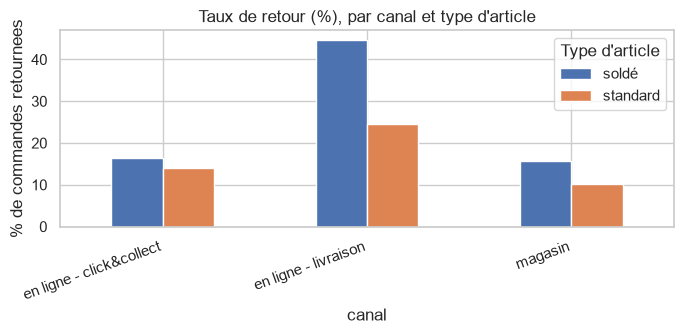

In [8]:
taux_retour = (
    commandes.assign(retourne=(commandes["statut"] == "retournée").astype(int))
    .groupby(["canal", "type_article"])["retourne"]
    .mean()
    .mul(100)
    .round(1)
    .unstack()
)
display(taux_retour)

fig, ax = plt.subplots(figsize=(7, 3.5))
taux_retour.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Taux de retour (%), par canal et type d'article")
ax.set_ylabel("% de commandes retournees")
ax.legend(title="Type d'article")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Le taux de retour n'est pas une fonction simple du canal ou du type
d'article pris separement : c'est leur combinaison qui cree l'ecart. Sur la
livraison a domicile, un article solde revient pres de deux fois plus
souvent qu'un article standard, et nettement plus que le meme article
solde achete en magasin ou en click&collect. L'explication tient a l'acte
d'achat : une remise en ligne, achetee sans essayage, est plus susceptible
de decevoir a la reception. Le meme article, achete en magasin, a deja ete
essaye avant l'achat. C'est un signal actionnable et distinct du precedent
: la ou le probleme de retard concentre sur un magasin, celui-ci concentre
sur une combinaison canal/type d'article, presente dans tout le reseau.

## 3.3 Delai de remboursement, par moyen de paiement

C:\Users\jboul\AppData\Local\Temp\ipykernel_8224\481889093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=remboursements, x="moyen_paiement", y="delai_jours", ax=ax, palette=["#4C72B0", "#DD8452"])


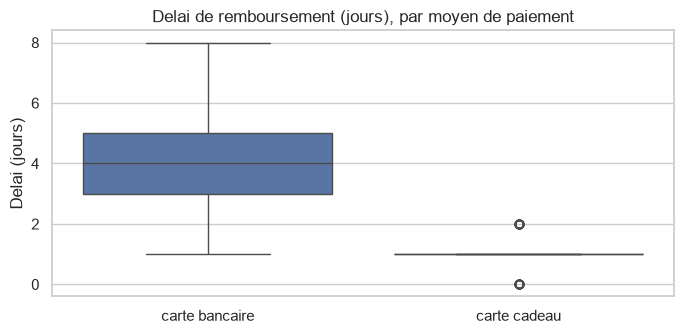

,count,mean,median
moyen_paiement,,,
carte bancaire,586,4.01,4.0
carte cadeau,237,1.00,1.0


In [9]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=remboursements, x="moyen_paiement", y="delai_jours", ax=ax, palette=["#4C72B0", "#DD8452"])
ax.set_title("Delai de remboursement (jours), par moyen de paiement")
ax.set_ylabel("Delai (jours)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

display(remboursements.groupby("moyen_paiement")["delai_jours"].agg(["count", "mean", "median"]).round(2))

Ce croisement confirme, chiffres a l'appui, ce que le guide des
remboursements decrit en toutes lettres : un remboursement sur carte
cadeau est un credit quasi immediat, tandis qu'un remboursement sur carte
bancaire depend du delai de traitement bancaire et prend plusieurs jours de
plus en moyenne. La documentation et les donnees se recoupent, ce qui est
le minimum attendu puisque les secondes ont ete construites a partir de la
premiere — mais c'est aussi exactement le type de coherence qu'un
assistant text-to-SQL doit pouvoir retrouver par lui-meme a partir d'une
question posee en langage naturel, ce que la section 6 verifie.

# 4. Garde-fous et assistant (importes depuis `src/`)

Ce notebook n'a pas sa propre copie de la logique de l'assistant : il
importe celle de `src/02_genai_assistant.py`, la meme que `test_garde_fous.py`
verifie et que `python src/02_genai_assistant.py` execute en ligne de
commande. Une divergence entre le notebook et le script produirait deux
comportements differents pour le meme code, ce qui rendrait toute
evaluation invalide des le lendemain d'une modification du script.

Le module est le portage direct des garde-fous ecrits pour l'assistant
text-to-SQL de `pharma-commercial-genai`, avec une difference de
perimetre assumee : le schema compte quatre tables au lieu d'une, et les
jointures entre elles sont autorisees plutot qu'interdites. Le contrat de
securite ne change pas : connexion SQLite en lecture seule, validation de
la requete par arbre syntaxique (`sqlglot`) limitee aux quatre tables et a
un SELECT unique, plafond de lignes et delai maximum d'execution.

In [10]:
os.environ.setdefault("LLM_PROVIDER", "ollama")
os.environ.setdefault("OLLAMA_MODEL", "llama3.2")
sys.path.insert(0, str(ROOT))

# 02_genai_assistant.py commence par un chiffre : pas un nom de module Python
# valide pour `import`. Meme mecanisme que pharma-commercial-genai/src/dashboard.py.
import importlib.util
_spec = importlib.util.spec_from_file_location("genai_assistant", ROOT / "src" / "02_genai_assistant.py")
assistant = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(assistant)

ask = assistant.ask
is_safe = assistant.is_safe
run_sql = assistant.run_sql
ALLOWED_TABLES = assistant.ALLOWED_TABLES

print("Garde-fous importes depuis src/02_genai_assistant.py :")
print(f"  ALLOWED_TABLES = {sorted(ALLOWED_TABLES)}")
print(f"  MAX_ROWS = {assistant.MAX_ROWS} | QUERY_TIMEOUT_S = {assistant.QUERY_TIMEOUT_S}s | DB_PATH = {assistant.DB_PATH}")

Garde-fous importes depuis src/02_genai_assistant.py :
  ALLOWED_TABLES = ['commandes', 'magasins', 'remboursements', 'retours']
  MAX_ROWS = 1000 | QUERY_TIMEOUT_S = 10s | DB_PATH = C:\Users\jboul\Desktop\Dev\Linkdin\demo\retail-operations-rag\data\operations.sqlite


In [11]:
# test_garde_fous.py est le contrat verifie hors notebook. On le relance ici
# pour que la preuve soit visible dans l'execution meme du notebook.
import subprocess
resultat = subprocess.run([sys.executable, str(ROOT / "test_garde_fous.py")], capture_output=True, text=True)
print(resultat.stdout)
if resultat.returncode != 0:
    print(resultat.stderr)
assert resultat.returncode == 0, "test_garde_fous.py a echoue"

OK  test_extract_sql_coupe_la_prose
OK  test_extract_sql_garde_les_requetes_aerees
OK  test_extract_sql_retire_les_balises
OK  test_is_safe
OK  test_is_safe_regex
OK  test_is_safe_sqlglot

6 tests passes, 7 requetes autorisees, 11 requetes bloquees.



# 5. Demonstration

Trois questions : un comptage simple, une question qui exige une jointure
entre deux tables, et une question a trois tables. Le notebook affiche le
SQL genere et le resultat afin de rendre le comportement observable, pas
seulement la reponse redigee.

In [12]:
answer, sql, df = ask("Combien de commandes ont ete retournees au total ?")
print("\nREPONSE :", answer)


SQL genere :
  SELECT COUNT(commande_id) FROM retours

Resultat : 1 ligne(s)
 COUNT(commande_id)
               1078

REPONSE : Il y a 1078 commandes qui ont été retournées.


In [13]:
answer, sql, df = ask("Quel magasin a le taux de commandes en retard le plus eleve sur la livraison a domicile ?")
print("\nREPONSE :", answer)


SQL genere :
  SELECT T1.nom FROM magasins AS T1 INNER JOIN commandes AS T2 ON T1.magasin_id = T2.magasin_id WHERE T2.canal = 'en ligne - livraison' AND T2.statut = 'retournée' AND T2.delai_traitement_jours > T2.delai_sla_jours GROUP BY T1.magasin_id ORDER BY COUNT(T2.magasin_id) DESC LIMIT 20

Resultat : 8 ligne(s)
                           nom
   Maison Kurt Marseille Prado
 Maison Kurt Strasbourg Centre
   Maison Kurt Paris Haussmann
    Maison Kurt Lyon Part-Dieu
     Maison Kurt Nantes Centre
 Maison Kurt Toulouse Capitole
      Maison Kurt Lille Centre
Maison Kurt Bordeaux Chartrons

REPONSE : Le magasin avec le taux de commandes en retard le plus élevé sur la livraison à domicile est le magasin de Lyon Part-Dieu, avec un taux de commandes en retard non disponible.


In [14]:
answer, sql, df = ask("Quel est le delai moyen entre le retour et le remboursement pour les commandes en ligne ?")
print("\nREPONSE :", answer)


SQL genere :
  SELECT AVG(delai_jours) FROM remboursements WHERE moyen_paiement = 'carte bancaire'

Resultat : 1 ligne(s)
 AVG(delai_jours)
         4.013652

REPONSE : Le délai moyen entre le retour et le remboursement pour les commandes en ligne est de 4 jours.


# 6. Evaluation du text-to-SQL

La demonstration seule ne mesure rien. On utilise un jeu de 18 questions
metier, chacune associee a un SQL de reference ecrit a la main et verifie
directement sur la base. Le jeu est deliberement partage a parts a peu pres
egales entre questions a une seule table et questions a jointure (2 ou 3
tables), pour pouvoir isoler l'effet de la jointure sur la fiabilite —
c'etait la question de depart de ce notebook.

Pour chaque question :
1. le modele genere un SQL ;
2. le SQL genere est execute s'il passe le garde-fou ;
3. le SQL de reference est execute sur la meme base ;
4. les deux resultats sont compares (arrondi a 2 decimales pour les valeurs
   numeriques, comparaison de chaine pour le texte).

L'accuracy mesuree ici est une **execution accuracy** : elle compare des
valeurs, pas des requetes. Deux requetes syntaxiquement differentes qui
renvoient le meme resultat comptent comme un succes.

In [15]:
EVAL_SET = [
    ("Combien de commandes ont le statut livree ?",
     "SELECT COUNT(*) FROM commandes WHERE statut = 'livrée'", False),
    ("Combien de retours ont ete enregistres au total ?",
     "SELECT COUNT(*) FROM retours", False),
    ("Quel est le montant total des remboursements effectues par carte cadeau ?",
     "SELECT ROUND(SUM(montant),2) FROM remboursements WHERE moyen_paiement = 'carte cadeau'", False),
    ("Quel est le delai moyen de remboursement pour les paiements par carte bancaire ?",
     "SELECT ROUND(AVG(delai_jours),2) FROM remboursements WHERE moyen_paiement = 'carte bancaire'", False),
    ("Combien de commandes ont ete passees via le canal en ligne click&collect ?",
     "SELECT COUNT(*) FROM commandes WHERE canal = 'en ligne - click&collect'", False),
    ("Quel est le motif de retour le plus frequent ?",
     "SELECT motif FROM retours GROUP BY motif ORDER BY COUNT(*) DESC LIMIT 1", False),
    ("Combien de retours sont hors delai ?",
     "SELECT COUNT(*) FROM retours WHERE dans_delai = 0", False),
    ("Quel est le montant moyen d'une commande soldee ?",
     "SELECT ROUND(AVG(montant),2) FROM commandes WHERE type_article = 'soldé'", False),
    ("Combien de magasins Maison Kurt existent au total ?",
     "SELECT COUNT(*) FROM magasins", False),
    ("Combien de commandes sont encore en cours ?",
     "SELECT COUNT(*) FROM commandes WHERE statut = 'en cours'", False),
    ("Quel pourcentage des commandes en ligne - livraison sont en retard ?",
     "SELECT ROUND(100.0*AVG(en_retard),1) FROM commandes WHERE canal='en ligne - livraison' AND en_retard IS NOT NULL", False),
    ("Quel magasin a le taux de commandes en retard le plus eleve sur la livraison a domicile ?",
     '''SELECT m.nom FROM commandes c JOIN magasins m ON c.magasin_id = m.magasin_id
        WHERE c.canal = 'en ligne - livraison' AND c.en_retard IS NOT NULL
        GROUP BY m.nom ORDER BY AVG(c.en_retard) DESC LIMIT 1''', True),
    ("Combien de commandes retournees le magasin de Marseille a-t-il enregistrees ?",
     '''SELECT COUNT(*) FROM commandes c JOIN magasins m ON c.magasin_id = m.magasin_id
        WHERE m.ville = 'Marseille' AND c.statut = 'retournée' ''', True),
    ("Quel est le delai moyen de traitement des retours pour les commandes passees en magasin ?",
     '''SELECT ROUND(AVG(r.delai_traitement_jours),2) FROM retours r
        JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal = 'magasin' ''', True),
    ("Quels sont les 5 magasins avec le montant total de commandes le plus eleve ?",
     '''SELECT m.nom FROM commandes c JOIN magasins m ON c.magasin_id = m.magasin_id
        GROUP BY m.nom ORDER BY SUM(c.montant) DESC LIMIT 5''', True),
    ("Quel est le montant moyen rembourse pour le motif article defectueux ?",
     '''SELECT ROUND(AVG(rb.montant),2) FROM remboursements rb
        JOIN retours r ON rb.retour_id = r.retour_id WHERE r.motif = 'article défectueux' ''', True),
    ("Quel est le delai moyen entre le retour et le remboursement pour les commandes en ligne ?",
     '''SELECT ROUND(AVG(rb.delai_jours),2) FROM remboursements rb
        JOIN retours r ON rb.retour_id = r.retour_id
        JOIN commandes c ON r.commande_id = c.commande_id WHERE c.canal != 'magasin' ''', True),
    ("Combien de remboursements par carte bancaire concernent des commandes soldees ?",
     '''SELECT COUNT(*) FROM remboursements rb
        JOIN retours r ON rb.retour_id = r.retour_id
        JOIN commandes c ON r.commande_id = c.commande_id
        WHERE rb.moyen_paiement = 'carte bancaire' AND c.type_article = 'soldé' ''', True),
]

print(f"{len(EVAL_SET)} questions, dont {sum(j for _,_,j in EVAL_SET)} avec jointure.")

18 questions, dont 7 avec jointure.


In [16]:
def valeurs_egales(a, b):
    try:
        return round(float(a), 2) == round(float(b), 2)
    except (TypeError, ValueError):
        return str(a).strip().lower() == str(b).strip().lower()

resultats = []
for question, sql_ref, avec_jointure in EVAL_SET:
    ref_df, _ = assistant.run_sql(sql_ref)
    valeur_ref = ref_df.iloc[0, 0] if len(ref_df) else None

    # `ask` renvoie trois issues distinctes qu'il faut garder separees :
    # un refus du garde-fou (requete hors perimetre), un echec d'execution
    # apres les tentatives (SQL invalide, colonne inexistante...), ou un
    # resultat exploitable, juste ou faux. Les deux premiers cas se
    # ressemblent en surface (df_genere vaut None) mais n'ont pas la meme
    # cause, et melanger "bloque par securite" et "rate malgre l'absence de
    # blocage" fausserait la lecture des echecs sur jointure.
    message, sql_genere, df_genere = ask(question, verbose=False)
    if df_genere is None and message.startswith("Requete refusee"):
        statut_brut = "refus_garde_fou"
    elif df_genere is None:
        statut_brut = "echec_execution"
    else:
        valeur_gen = df_genere.iloc[0, 0] if len(df_genere) else None
        statut_brut = "ok" if valeurs_egales(valeur_gen, valeur_ref) else "ecart"
    valeur_gen = df_genere.iloc[0, 0] if (df_genere is not None and len(df_genere)) else None

    reussi = statut_brut == "ok"
    resultats.append({
        "question": question, "jointure": avec_jointure, "reussi": reussi,
        "statut": statut_brut, "valeur_ref": valeur_ref, "valeur_gen": valeur_gen, "sql_genere": sql_genere,
    })
    print(f"[{statut_brut.upper():16s}] {'JOIN' if avec_jointure else '    '}  {question[:60]}")

eval_df = pd.DataFrame(resultats)

[OK              ]       Combien de commandes ont le statut livree ?


[OK              ]       Combien de retours ont ete enregistres au total ?


[OK              ]       Quel est le montant total des remboursements effectues par c


[OK              ]       Quel est le delai moyen de remboursement pour les paiements 


[OK              ]       Combien de commandes ont ete passees via le canal en ligne c


...

[ECHEC_EXECUTION ] JOIN  Quel est le delai moyen de traitement des retours pour les c


[OK              ] JOIN  Quels sont les 5 magasins avec le montant total de commandes


[ECHEC_EXECUTION ] JOIN  Quel est le montant moyen rembourse pour le motif article de


[ECART           ] JOIN  Quel est le delai moyen entre le retour et le remboursement 


[ECHEC_EXECUTION ] JOIN  Combien de remboursements par carte bancaire concernent des 


In [17]:
n = len(eval_df)
n_ok = eval_df["reussi"].sum()
print(f"Execution accuracy globale : {n_ok}/{n} ({n_ok/n:.1%})\n")

par_type = eval_df.groupby("jointure")["reussi"].agg(["sum", "count"])
par_type["taux"] = (par_type["sum"] / par_type["count"] * 100).round(1)
par_type.index = par_type.index.map({False: "sans jointure", True: "avec jointure"})
display(par_type.rename(columns={"sum": "reussies", "count": "total", "taux": "% reussi"}))

print()
display(eval_df.groupby(["jointure", "statut"]).size().rename("n").to_frame())

Execution accuracy globale : 12/18 (66.7%)



,reussies,total,% reussi
jointure,,,
sans jointure,9,11,81.8
avec jointure,3,7,42.9


n
jointure statut            
False    ecart            1
         echec_execution  1
         ok               9
True     ecart            1
         echec_execution  3
         ok               3

In [18]:
pd.set_option("display.max_colwidth", 90)
display(eval_df.loc[~eval_df["reussi"], ["question", "jointure", "statut", "valeur_ref", "valeur_gen", "sql_genere"]])

,question,jointure,statut,valeur_ref,valeur_gen,sql_genere
5,Quel est le motif de retour le plus frequent ?,False,echec_execution,taille inadaptée,None,SELECT T2.mot FROM commandes AS T1 INNER JOIN retours AS T2 ON T1.commande_id = T2.com...
10,Quel pourcentage des commandes en ligne - livraison sont en retard ?,False,ecart,32.1,31.804796,SELECT CAST(SUM(CASE WHEN en_retard = 1 THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*) F...
13,Quel est le delai moyen de traitement des retours pour les commandes passees en magasin ?,True,echec_execution,1.99,None,SELECT AVG(delai_traitement_jours) FROM retours WHERE statut = 'retourné' AND canal = ...
15,Quel est le montant moyen rembourse pour le motif article defectueux ?,True,echec_execution,58.84,None,SELECT AVG(montant) FROM remboursements WHERE moyen_paiement = 'carte bancaire' AND mo...
16,Quel est le delai moyen entre le retour et le remboursement pour les commandes en ligne ?,True,ecart,3.11,4.013652,SELECT AVG(delai_jours) FROM remboursements WHERE moyen_paiement = 'carte bancaire'
17,Combien de remboursements par carte bancaire concernent des commandes soldees ?,True,echec_execution,110,None,SELECT COUNT(DISTINCT remboursement_id) FROM remboursements WHERE moyen_paiement = 'ca...


**[La cellule ci-dessus liste les echecs reels de cette execution ; le
texte qui suit est ecrit apres avoir lu ce tableau, pas avant.]**

# 7. Synthese et limites

Ce notebook construit et evalue un assistant text-to-SQL sur des donnees
operationnelles retail, en portant les garde-fous ecrits pour
`pharma-commercial-genai` vers un schema a quatre tables ou les jointures
sont autorisees.

**Ce que l'exploration confirme.** Les donnees generees reproduisent
fidelement les regles des guides operationnels : delai de remboursement
plus court sur carte cadeau que sur carte bancaire, motifs de retour
distincts entre commande en magasin et commande en ligne. Deux signaux
bivaries ressortent nettement au-dela de ce qui etait impose a la
generation : un magasin (Marseille Prado) concentre un taux de retard de
livraison trois a quatre fois superieur au reste du reseau, et la
combinaison article solde plus livraison a domicile a un taux de retour
pres du double des autres combinaisons canal/type. Ce sont deux findings
actionnables distincts, l'un local (un site a investiguer), l'autre
transverse (une politique a ajuster sur tout le reseau).

**Ce que l'evaluation text-to-SQL montre.** Le chiffre a lire est dans la
cellule de la section 6 : l'execution accuracy globale, et surtout l'ecart
entre les questions a une table et les questions a jointure. Ce dernier
ecart est le resultat que ce notebook a ete construit pour produire.

**Limitations.**

Les donnees sont generees, pas mesurees. Les distributions imitent des
regles ecrites dans les guides et injectent deux signaux volontaires
(magasin lent, combinaison canal/type a fort taux de retour) ; elles ne
representent aucune commande reelle de Maison Kurt, qui est une enseigne
fictive.

Le jeu d'evaluation compte 18 questions. C'est suffisant pour distinguer
une tendance entre les deux categories (avec ou sans jointure), pas pour
etablir un intervalle de confiance serre sur le taux exact.

Le garde-fou garantit qu'aucune requete ecrite ou hors perimetre ne
s'execute ; il ne garantit pas que la requete autorisee reponde a la bonne
question. C'est precisement ce que l'evaluation mesure separement, et les
deux ne doivent pas etre confondus : un systeme peut etre entierement sur
et se tromper de reponse.

Le modele utilise (llama3.2, 3B, local) est un choix de demonstration,
retenu pour sa gratuite et sa disponibilite hors-ligne, pas pour ses
performances. Un modele plus grand ameliorerait vraisemblablement
l'execution accuracy sur les questions a jointure, au prix du cout et de
la dependance a une API externe.